# Convergence and 1D benchmark

Run grid refinement and the analytic 1D comparison, then show results.


## Setup


In [1]:
from pathlib import Path
import os
import sys
import subprocess
import matplotlib.pyplot as plt

repo_root = Path().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

# Helper to run CLI modules with correct PYTHONPATH
_env = os.environ.copy()
_env["PYTHONPATH"] = str(repo_root / "src")

def run_module(module, args):
    cmd = [sys.executable, "-m", module] + list(args)
    return subprocess.run(cmd, check=True, env=_env)

print("repo_root:", repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Grid refinement (V1)


In [2]:
run_module("scripts.sim.benchmark_v1", ["--config", "configs/sim/v1_baseline.yaml"])
print("Saved: figures/validation/v1_convergence.png")


Saved: figures/validation/v1_convergence.png


## Convergence figure


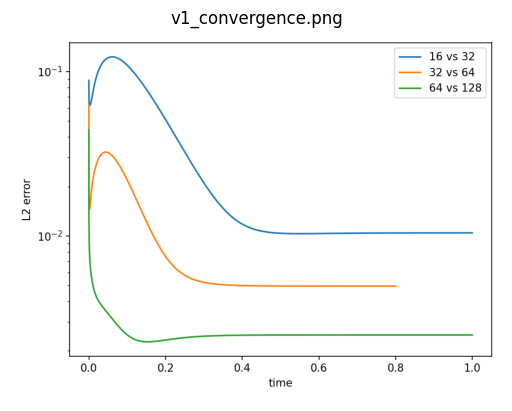

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

img = Path("figures/validation/v1_convergence.png")
if img.exists():
    plt.figure()
    plt.imshow(plt.imread(img))
    plt.axis("off")
    plt.title(img.name)
    plt.show()
else:
    print("Missing:", img)


## Analytic 1D comparison


In [4]:
run_module("scripts.sim.benchmark_v1_1d", ["--config", "configs/sim/v1_baseline.yaml"])


CompletedProcess(args=['c:\\Users\\nwals\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', '-m', 'scripts.sim.benchmark_v1_1d', '--config', 'configs/sim/v1_baseline.yaml'], returncode=0)

## Load reports and inspect summaries


In [5]:
from pathlib import Path
import json

report_path = Path("outputs/sim/v1/benchmark/report.json")
report_1d_path = Path("outputs/sim/v1/benchmark/report_1d.json")

report = json.loads(report_path.read_text())
report_1d = json.loads(report_1d_path.read_text())

print("grid refinement summary:")
for k, v in report["summary"].items():
    print(k, v)

print("1d errors:", report_1d.get("errors"))


grid refinement summary:
16_vs_32 {'mean': 0.029851783637035296, 'final': 0.010443718631572493, 'max': 0.12295470382822694}
32_vs_64 {'mean': 0.008936896744664058, 'final': 0.004956370969118494, 'max': 0.0625}
64_vs_128 {'mean': 0.0025984153289432778, 'final': 0.0024993219798361693, 'max': 0.04419417382415922}
1d errors: [0.0, 2.659040778042563e-09, 1.663728033798943e-14]
